In [5]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_monthly_summary.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_yearly_performance.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [7]:
file_path = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (33364, 15)


,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,241.886714,241.886714,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,5.820864,248.926662,248.926662,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-2.882097,248.814243,248.814243,6.153922,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,13.341583,257.049474,257.049474,8.119016,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.228372,262.119303,262.119303,7.120498,16.748297,2024-12


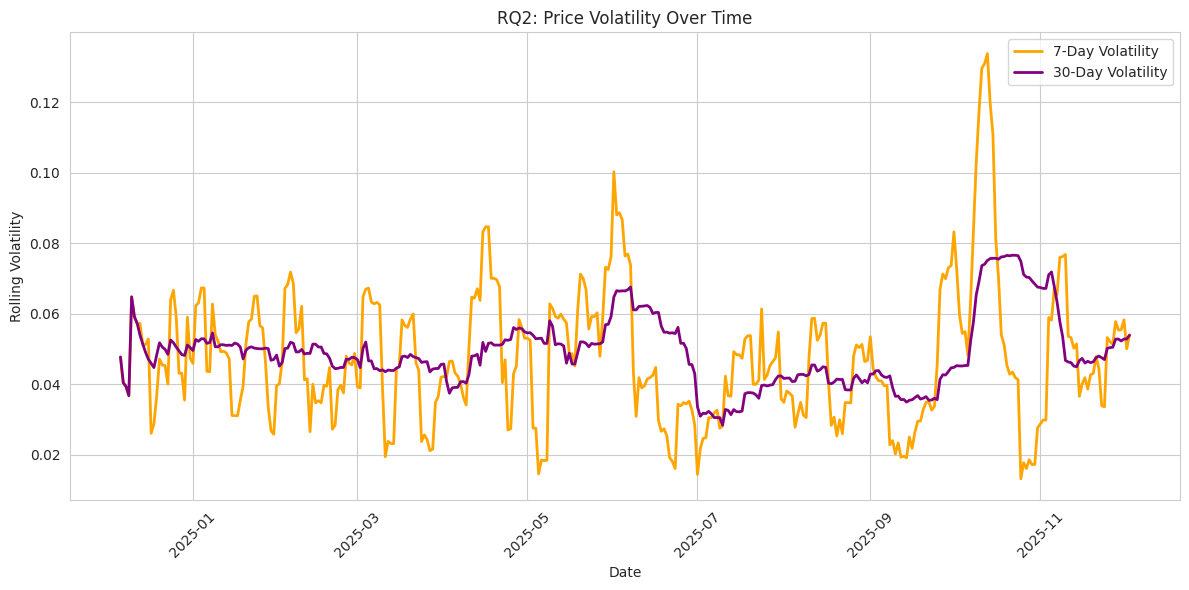

In [8]:
# RQ2: How does price volatility vary over time, and can it be quantitatively modeled?

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])

# Build a daily market-level series using median price across all coins
daily_vol = (
    df.groupby("date")
      .agg(median_price=("price", "median"))
      .reset_index()
      .sort_values("date")
)

# Daily return
daily_vol["daily_return"] = daily_vol["median_price"].pct_change()

# Quantitative volatility modeling using rolling standard deviation of returns
daily_vol["volatility_7d"] = daily_vol["daily_return"].rolling(window=7, min_periods=2).std()
daily_vol["volatility_30d"] = daily_vol["daily_return"].rolling(window=30, min_periods=2).std()

# Save main volatility table
daily_vol.to_csv("/kaggle/working/RQ2_volatility_over_time.csv", index=False)

# Save summary statistics table
summary = daily_vol[["median_price", "daily_return", "volatility_7d", "volatility_30d"]].describe().round(6)
summary.to_csv("/kaggle/working/RQ2_volatility_summary.csv")

# Plot volatility over time
plt.figure(figsize=(12, 6))
plt.plot(daily_vol["date"], daily_vol["volatility_7d"], label="7-Day Volatility", color="orange", linewidth=2)
plt.plot(daily_vol["date"], daily_vol["volatility_30d"], label="30-Day Volatility", color="purple", linewidth=2)

plt.title("RQ2: Price Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("/kaggle/working/RQ2_volatility_over_time.pdf")
plt.show()
